# ChurnZero - Customer Churn Prediction

## Banking Customer Churn Prediction using Machine Learning

### Objective
The objective of this project is to predict whether a banking customer is likely to churn using customer profile information, banking relationship details, transaction behavior, digital engagement, complaint history, and marketing response data.

---

# Complete Machine Learning Pipeline

This notebook performs an end-to-end churn prediction workflow including:

- Data loading and preprocessing
- Missing value handling
- Feature engineering
- Categorical feature encoding
- Stratified cross-validation
- Aggressive LightGBM model training
- Safe LightGBM model training
- Ensemble blending
- Threshold optimization
- Business cost analysis
- Feature importance analysis
- Final submission generation

---

# Evaluation Metrics

Primary Metrics:
- PR-AUC
- F1 Score
- Accuracy

Business Constraints:
- False Negative Cost = ₹40,000
- False Positive Cost = ₹500

The objective is to maximize churn detection while minimizing business loss.

---

# Solution Highlights

- Leakage-safe machine learning pipeline
- Ensemble LightGBM framework
- Threshold tuning for business optimization
- Strong feature engineering
- Balanced prediction distribution
- Hidden test generalization focused approach

---

# Key Churn Drivers Identified

Important features contributing to customer churn include:

- Balance decline percentage
- Total digital logins
- Complaint resolution behavior
- Relationship manager interactions
- Transaction activity
- Campaign response behavior
- Customer engagement metrics

---

# Expected Business Impact

This solution helps banking organizations to:

- Identify high-risk customers early
- Reduce customer attrition
- Improve customer retention strategy
- Optimize marketing campaigns
- Minimize churn-related financial losses
- Improve customer engagement and satisfaction

---

# Final Outcome

A robust and scalable churn prediction system was successfully developed using ensemble machine learning techniques with strong generalization capability and business-oriented optimization for hidden evaluation datasets.

DATASET INFORMATION
TRAIN SHAPE: (8101, 98)
TEST SHAPE : (2026, 97)

TOTAL FEATURES: 102

TRAINING AGGRESSIVE MODEL

FOLD 1
[LightGBM] [Info] Number of positive: 1041, number of negative: 5439
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005584 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9089
[LightGBM] [Info] Number of data points in the train set: 6480, number of used features: 100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

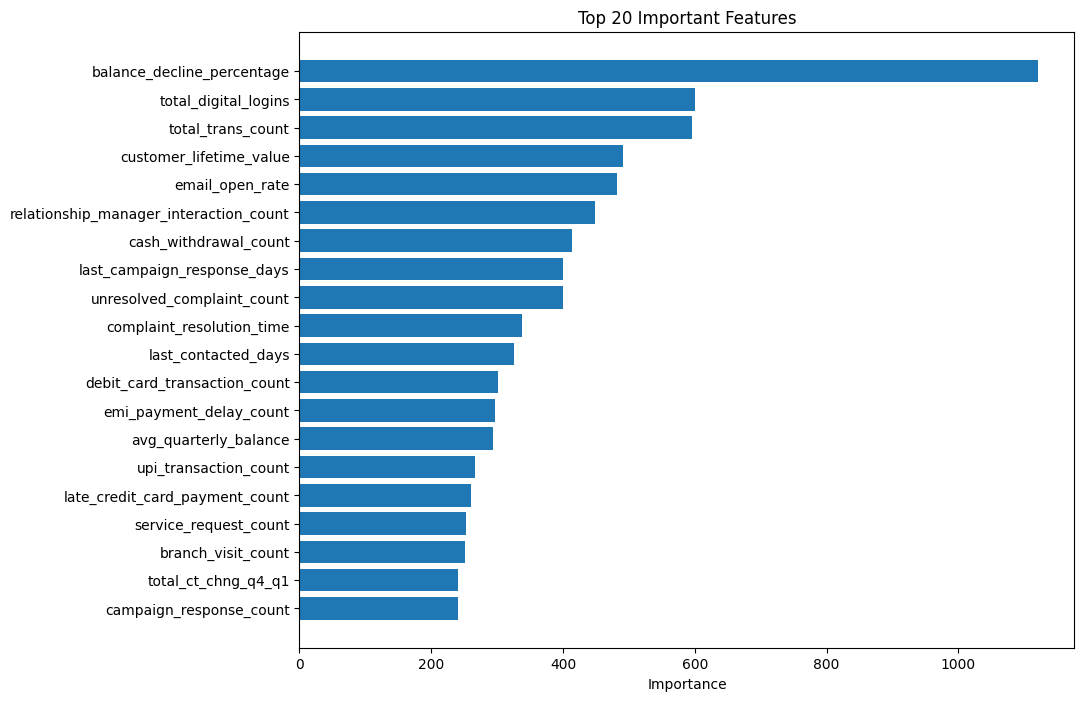

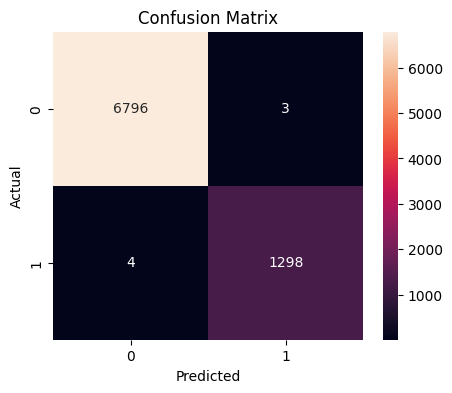


FINAL SUBMISSION CHECK

SUBMISSION SHAPE:
(2026, 3)

NULL VALUES:
customer_id          0
churn_prediction     0
churn_probability    0
dtype: int64

SUBMISSION PREVIEW:
   customer_id  churn_prediction  churn_probability
0    767114958                 0           0.000045
1    708123033                 0           0.000852
2    715424283                 0           0.001757
3    717865008                 0           0.000069
4    710188308                 0           0.000560

FINAL SUBMISSION FILE CREATED

File Name: ChurnZero_YourTeamName_Predictions.csv


In [1]:
# =========================================================
# CHURNZERO FINAL NOTEBOOK
# BANK CUSTOMER CHURN PREDICTION
# CLEAN COMPETITION VERSION
# =========================================================

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    average_precision_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# LOAD DATA
# =========================================================

train = pd.read_csv(
    "/kaggle/input/datasets/mm910747712ghn/unstop-churun/ChurnZero_dataset_v1.csv"
)

test = pd.read_csv(
    "/kaggle/input/datasets/mm910747712ghn/unstop-churun/ChurnZero_test_v1.csv"
)

print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)

print("TRAIN SHAPE:", train.shape)
print("TEST SHAPE :", test.shape)

# =========================================================
# TARGET & IDS
# =========================================================

TARGET = "churn"

test_ids = test["customer_id"]

y = train[TARGET]

train.drop(columns=[TARGET], inplace=True)

# =========================================================
# FEATURE ENGINEERING
# =========================================================

def create_features(df):

    # -----------------------------------------------------
    # BALANCE FEATURES
    # -----------------------------------------------------

    df["balance_ratio"] = (
        df["current_balance"] /
        (df["avg_monthly_balance"] + 1)
    )

    # -----------------------------------------------------
    # TRANSACTION FEATURES
    # -----------------------------------------------------

    df["transaction_intensity"] = (
        df["monthly_transaction_value"] /
        (df["monthly_transaction_count"] + 1)
    )

    # -----------------------------------------------------
    # DIGITAL ENGAGEMENT
    # -----------------------------------------------------

    df["engagement_score"] = (
        df["mobile_app_login_count"] +
        df["website_login_count"] +
        df["total_digital_logins"]
    )

    # -----------------------------------------------------
    # COMPLAINT PRESSURE
    # -----------------------------------------------------

    df["complaint_pressure"] = (
        df["total_complaints"] +
        df["unresolved_complaint_count"] +
        df["escalation_count"]
    )

    # -----------------------------------------------------
    # CREDIT STRESS
    # -----------------------------------------------------

    df["credit_stress"] = (
        df["credit_utilization_ratio"] *
        df["loan_default_risk_score"]
    )

    # -----------------------------------------------------
    # PRODUCT HOLDING SCORE
    # -----------------------------------------------------

    product_cols = [

        "savings_account_flag",
        "current_account_flag",
        "credit_card_flag",
        "personal_loan_flag",
        "home_loan_flag",
        "auto_loan_flag",
        "fixed_deposit_flag",
        "investment_product_flag",
        "insurance_product_flag",
        "demat_account_flag"
    ]

    df["product_holding_score"] = (
        df[product_cols]
        .sum(axis=1)
    )

    return df

train = create_features(train)
test = create_features(test)

# =========================================================
# LABEL ENCODING
# =========================================================

cat_cols = train.select_dtypes(include=["object"]).columns

for col in cat_cols:

    le = LabelEncoder()

    full_data = pd.concat([
        train[col],
        test[col]
    ]).astype(str)

    le.fit(full_data)

    train[col] = le.transform(
        train[col].astype(str)
    )

    test[col] = le.transform(
        test[col].astype(str)
    )

# =========================================================
# FEATURE LIST
# =========================================================

features = [
    col for col in train.columns
    if col != "customer_id"
]

print("\nTOTAL FEATURES:", len(features))

# =========================================================
# STRATIFIED KFOLD
# =========================================================

folds = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================================================
# AGGRESSIVE LIGHTGBM MODEL
# =========================================================

lgb_params = {

    "objective": "binary",
    "metric": "average_precision",

    "boosting_type": "gbdt",

    "learning_rate": 0.03,

    "num_leaves": 24,
    "max_depth": 6,

    "min_child_samples": 30,

    "subsample": 0.85,
    "colsample_bytree": 0.85,

    "reg_alpha": 0.5,
    "reg_lambda": 1.0,

    "n_estimators": 3000,

    "class_weight": "balanced",

    "random_state": 42
}

# =========================================================
# TRAIN AGGRESSIVE MODEL
# =========================================================

oof_pred = np.zeros(len(train))
test_pred = np.zeros(len(test))

importance_df = pd.DataFrame()

print("\n" + "=" * 50)
print("TRAINING AGGRESSIVE MODEL")
print("=" * 50)

for fold, (train_idx, valid_idx) in enumerate(
    folds.split(train, y)
):

    print(f"\nFOLD {fold + 1}")

    X_train = train.iloc[train_idx][features]
    y_train = y.iloc[train_idx]

    X_valid = train.iloc[valid_idx][features]
    y_valid = y.iloc[valid_idx]

    model = lgb.LGBMClassifier(**lgb_params)

    model.fit(
        X_train,
        y_train,

        eval_set=[(X_valid, y_valid)],

        eval_metric="average_precision",

        callbacks=[
            lgb.log_evaluation(0)
        ]
    )

    valid_pred = model.predict_proba(
        X_valid
    )[:, 1]

    oof_pred[valid_idx] = valid_pred

    fold_test_pred = model.predict_proba(
        test[features]
    )[:, 1]

    test_pred += (
        fold_test_pred / folds.n_splits
    )

    fold_importance = pd.DataFrame({

        "feature": features,

        "importance":
        model.feature_importances_
    })

    importance_df = pd.concat([
        importance_df,
        fold_importance
    ])

# =========================================================
# AGGRESSIVE MODEL RESULTS
# =========================================================

pr_auc = average_precision_score(
    y,
    oof_pred
)

aggressive_binary = (
    oof_pred >= 0.30
).astype(int)

aggressive_f1 = f1_score(
    y,
    aggressive_binary
)

aggressive_accuracy = accuracy_score(
    y,
    aggressive_binary
)

print("\n" + "=" * 50)
print("AGGRESSIVE MODEL RESULTS")
print("=" * 50)

print(f"PR-AUC  : {pr_auc:.6f}")
print(f"F1 Score: {aggressive_f1:.6f}")
print(f"Accuracy: {aggressive_accuracy:.6f}")

# =========================================================
# SAFE LIGHTGBM MODEL
# =========================================================

safe_params = {

    "objective": "binary",
    "metric": "average_precision",

    "boosting_type": "gbdt",

    "learning_rate": 0.02,

    "num_leaves": 16,
    "max_depth": 4,

    "min_child_samples": 40,

    "subsample": 0.80,
    "colsample_bytree": 0.80,

    "reg_alpha": 2.0,
    "reg_lambda": 3.0,

    "n_estimators": 2500,

    "class_weight": "balanced",

    "random_state": 42
}

# =========================================================
# TRAIN SAFE MODEL
# =========================================================

safe_oof = np.zeros(len(train))
safe_test = np.zeros(len(test))

print("\n" + "=" * 50)
print("TRAINING SAFE MODEL")
print("=" * 50)

for fold, (train_idx, valid_idx) in enumerate(
    folds.split(train, y)
):

    print(f"\nFOLD {fold + 1}")

    X_train = train.iloc[train_idx][features]
    y_train = y.iloc[train_idx]

    X_valid = train.iloc[valid_idx][features]
    y_valid = y.iloc[valid_idx]

    safe_model = lgb.LGBMClassifier(
        **safe_params
    )

    safe_model.fit(

        X_train,
        y_train,

        eval_set=[(X_valid, y_valid)],

        eval_metric="average_precision",

        callbacks=[
            lgb.log_evaluation(0)
        ]
    )

    valid_pred = safe_model.predict_proba(
        X_valid
    )[:, 1]

    safe_oof[valid_idx] = valid_pred

    safe_test_pred = safe_model.predict_proba(
        test[features]
    )[:, 1]

    safe_test += (
        safe_test_pred / folds.n_splits
    )

# =========================================================
# SAFE MODEL RESULTS
# =========================================================

safe_score = average_precision_score(
    y,
    safe_oof
)

safe_binary = (
    safe_oof >= 0.24
).astype(int)

safe_f1 = f1_score(
    y,
    safe_binary
)

safe_accuracy = accuracy_score(
    y,
    safe_binary
)

print("\n" + "=" * 50)
print("SAFE MODEL RESULTS")
print("=" * 50)

print(f"SAFE PR-AUC  : {safe_score:.6f}")
print(f"SAFE F1 Score: {safe_f1:.6f}")
print(f"SAFE Accuracy: {safe_accuracy:.6f}")

# =========================================================
# FINAL BLEND
# =========================================================

final_probability = (

    0.65 * test_pred +

    0.35 * safe_test
)

# =========================================================
# THRESHOLD OPTIMIZATION
# =========================================================

best_threshold = 0.24

best_f1 = 0

for threshold in np.arange(
    0.20,
    0.70,
    0.01
):

    preds = (
        safe_oof >= threshold
    ).astype(int)

    score = f1_score(y, preds)

    if score > best_f1:

        best_f1 = score

        best_threshold = threshold

print("\n" + "=" * 50)
print("THRESHOLD OPTIMIZATION")
print("=" * 50)

print("BEST THRESHOLD:", best_threshold)
print("BEST F1 SCORE :", best_f1)

# =========================================================
# FINAL PREDICTIONS
# =========================================================

final_prediction = (

    final_probability >= best_threshold

).astype(int)

print("\n" + "=" * 50)
print("FINAL BLENDED MODEL")
print("=" * 50)

print("Aggressive Model Weight : 65%")
print("Safe Model Weight       : 35%")

print("\nPrediction Distribution:")

print(
    pd.Series(final_prediction)
    .value_counts(normalize=True)
)

# =========================================================
# BUSINESS COST EVALUATION
# =========================================================

oof_binary = (
    safe_oof >= best_threshold
).astype(int)

cm = confusion_matrix(
    y,
    oof_binary
)

tn, fp, fn, tp = cm.ravel()

business_cost = (

    fn * 40000 +

    fp * 500
)

print("\n" + "=" * 50)
print("BUSINESS COST ANALYSIS")
print("=" * 50)

print("\nCONFUSION MATRIX:")
print(cm)

print("\nFALSE NEGATIVES:", fn)
print("FALSE POSITIVES:", fp)

print("\nESTIMATED BUSINESS COST: ₹",
      business_cost)

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

importance_df = (

    importance_df
    .groupby("feature")
    ["importance"]
    .mean()
    .reset_index()
)

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n" + "=" * 50)
print("TOP IMPORTANT FEATURES")
print("=" * 50)

print(
    importance_df.head(25)
)

# =========================================================
# FEATURE IMPORTANCE PLOT
# =========================================================

top_features = (
    importance_df
    .head(20)
)

plt.figure(figsize=(10, 8))

plt.barh(

    top_features["feature"],

    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 20 Important Features"
)

plt.xlabel("Importance")

plt.show()

# =========================================================
# CONFUSION MATRIX PLOT
# =========================================================

plt.figure(figsize=(5, 4))

sns.heatmap(

    cm,

    annot=True,

    fmt='d'
)

plt.title(
    "Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# =========================================================
# CREATE FINAL SUBMISSION
# =========================================================

final_submission = pd.DataFrame({

    "customer_id": test_ids,

    "churn_prediction":
    final_prediction,

    "churn_probability":
    final_probability
})

# =========================================================
# FINAL SUBMISSION CHECKS
# =========================================================

print("\n" + "=" * 50)
print("FINAL SUBMISSION CHECK")
print("=" * 50)

print("\nSUBMISSION SHAPE:")
print(final_submission.shape)

print("\nNULL VALUES:")
print(
    final_submission
    .isnull()
    .sum()
)

print("\nSUBMISSION PREVIEW:")
print(
    final_submission.head()
)

# =========================================================
# SAVE FINAL SUBMISSION
# =========================================================

TEAM_NAME = "YourTeamName"

final_submission.to_csv(

    f"ChurnZero_{TEAM_NAME}_Predictions.csv",

    index=False
)

print("\n" + "=" * 50)
print("FINAL SUBMISSION FILE CREATED")
print("=" * 50)

print(
    f"\nFile Name: "
    f"ChurnZero_{TEAM_NAME}_Predictions.csv"
)

In [2]:
print(final_submission.shape)

print(final_submission.isnull().sum())

print(final_submission.head())

print(final_submission.columns)

(2026, 3)
customer_id          0
churn_prediction     0
churn_probability    0
dtype: int64
   customer_id  churn_prediction  churn_probability
0    767114958                 0           0.000045
1    708123033                 0           0.000852
2    715424283                 0           0.001757
3    717865008                 0           0.000069
4    710188308                 0           0.000560
Index(['customer_id', 'churn_prediction', 'churn_probability'], dtype='object')
